<a href="https://colab.research.google.com/github/dvarelaj/nlp-miniproyecto-icesi/blob/main/mini_proyecto_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!git clone https://github.com/Ohtar10/icesi-nlp.git

Cloning into 'icesi-nlp'...
remote: Enumerating objects: 196, done.
remote: Counting objects: 100% (92/92), done.
remote: Compressing objects: 100% (20/20), done.
remote: Total 196 (delta 78), reused 72 (delta 72), pack-reused 104 (from 2)
Receiving objects: 100% (196/196), 4.32 MiB | 16.88 MiB/s, done.
Resolving deltas: 100% (100/100), done.


In [39]:
from datasets import load_dataset
import pandas as pd
import requests
import xml.etree.ElementTree as ET
import csv
import time
from tqdm import tqdm
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import RegexpTokenizer # Changed from word_tokenize
from wordcloud import WordCloud
from sklearn.preprocessing import LabelEncoder

In [12]:
# arxiv_oai_build_dataset.py
!pip install --quiet tqdm

# Config
OAI_ENDPOINT = "http://export.arxiv.org/oai2"
METADATA_PREFIX = "arXiv"
MAX_RECORDS = 20000        # máximo total a descargar (ajusta)
BATCH_SIZE = 200           # arXiv devuelve hasta 1000, pero 200 es seguro
FROM_DATE = "2022-01-01"           # formato YYYY-MM-DD (p.ej. "2020-01-01") o None
# OUT_CSV = "arxiv_metadata.csv" # No longer saving to CSV
SLEEP_BETWEEN = 1.0        # segundos entre requests para cortesía

ns = {
    'oai': 'http://www.openarchives.org/OAI/2.0/',
    'arxiv': 'http://arxiv.org/OAI/arXiv/'
}

def build_params(verb="ListRecords", metadataPrefix=METADATA_PREFIX, resumptionToken=None, from_date=None):
    params = {'verb': verb}
    if resumptionToken:
        params['resumptionToken'] = resumptionToken
    else:
        params['metadataPrefix'] = metadataPrefix
        if from_date:
            params['from'] = from_date
    return params

def parse_records(xml_text):
    root = ET.fromstring(xml_text)
    records = []
    for rec in root.findall('.//oai:record', ns):
        header = rec.find('oai:header', ns)
        if header is None or header.get('status') == 'deleted':
            continue
        meta = rec.find('oai:metadata', ns)
        if meta is None:
            continue
        arx = meta.find('arxiv:arXiv', ns)
        if arx is None:
            continue
        arxiv_id = arx.findtext('arxiv:id', default='', namespaces=ns)
        title = arx.findtext('arxiv:title', default='', namespaces=ns)
        abstract = arx.findtext('arxiv:abstract', default='', namespaces=ns)
        primary_cat = arx.findtext('arxiv:primary_category', default='', namespaces=ns)
        # fallback: categories node might appear differently
        if not primary_cat:
            cats = arx.findtext('arxiv:categories', default='', namespaces=ns)
            primary_cat = cats.split()[0] if cats else ''
        records.append({
            'id': arxiv_id.strip(),
            'title': (title or '').strip().replace('\n',' ').replace('\r',' '),
            'abstract': (abstract or '').strip().replace('\n',' ').replace('\r',' '),
            'primary_category': primary_cat.strip()
        })
    # resumptionToken (if any)
    rt = root.find('.//oai:resumptionToken', ns)
    token = rt.text.strip() if rt is not None and rt.text and rt.text.strip() else None
    return records, token

def harvest(max_records=MAX_RECORDS, batch_size=BATCH_SIZE, from_date=FROM_DATE):
    out = []
    token = None
    total = 0
    pbar = tqdm(total=max_records, desc="Harvesting")
    while total < max_records:
        params = build_params(resumptionToken=token, from_date=from_date)
        # optionally include set spec or metadataPrefix handled above
        try:
            r = requests.get(OAI_ENDPOINT, params=params, timeout=60)
            r.raise_for_status()
        except Exception as e:
            print("Request failed:", e)
            time.sleep(5)
            continue
        recs, token = parse_records(r.text)
        if not recs:
            break
        take = min(len(recs), max_records - total)
        out.extend(recs[:take])
        total += take
        pbar.update(take)
        if not token:
            break
        time.sleep(SLEEP_BETWEEN)
    pbar.close()
    return out

# Removed save_csv function as it's no longer needed for direct DataFrame loading
# def save_csv(records, path=OUT_CSV):
#     keys = ['id','title','abstract','primary_category']
#     with open(path, 'w', newline='', encoding='utf-8') as f:
#         writer = csv.DictWriter(f, fieldnames=keys)
#         writer.writeheader()
#         for r in records:
#             writer.writerow(r)
#     print(f"Saved {len(records)} records to {path}")

if __name__ == "__main__":
    print("Starting harvest from arXiv OAI-PMH...")
    recs = harvest()
    # Convert records to DataFrame instead of saving to CSV
    df_arxiv = pd.DataFrame(recs)
    print(f"Loaded {len(df_arxiv)} records into a Pandas DataFrame.")
    print("First 5 rows of the DataFrame:")
    display(df_arxiv.head())

Starting harvest from arXiv OAI-PMH...


Harvesting: 100%|██████████| 20000/20000 [01:57<00:00, 170.18it/s]

Loaded 20000 records into a Pandas DataFrame.
First 5 rows of the DataFrame:


,id,title,abstract,primary_category
0,1503.06364,Global stabilization of multiple integrators b...,"In this paper, we address the global stabiliza...",eess.SY
1,2011.06295,When deep learning models on GPU can be accele...,This paper is focused on the improvement the e...,cs.LG
2,2101.01990,Cross-Validation and Uncertainty Determination...,Randomized artificial neural networks such as ...,stat.ML
3,2101.09387,Online Adversarial Purification based on Self-...,Deep neural networks are known to be vulnerabl...,cs.LG
4,2102.00047,Model Adaptation for Image Reconstruction usin...,Deep learning image reconstruction algorithms ...,cs.LG


Total de registros: 20000
Total de categorías únicas: 153

Top 15 categorías más frecuentes:
primary_category
cs.LG                1336
cs.CV                 949
quant-ph              803
hep-ph                612
cond-mat.mtrl-sci     544
hep-th                515
astro-ph.GA           474
math.AP               469
cs.CL                 438
math.CO               405
gr-qc                 396
cond-mat.mes-hall     378
math.OC               356
math.NA               351
astro-ph.HE           333
Name: count, dtype: int64


/tmp/ipython-input-402/2696398682.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=category_counts.index[:15], y=category_counts.values[:15], palette="magma")


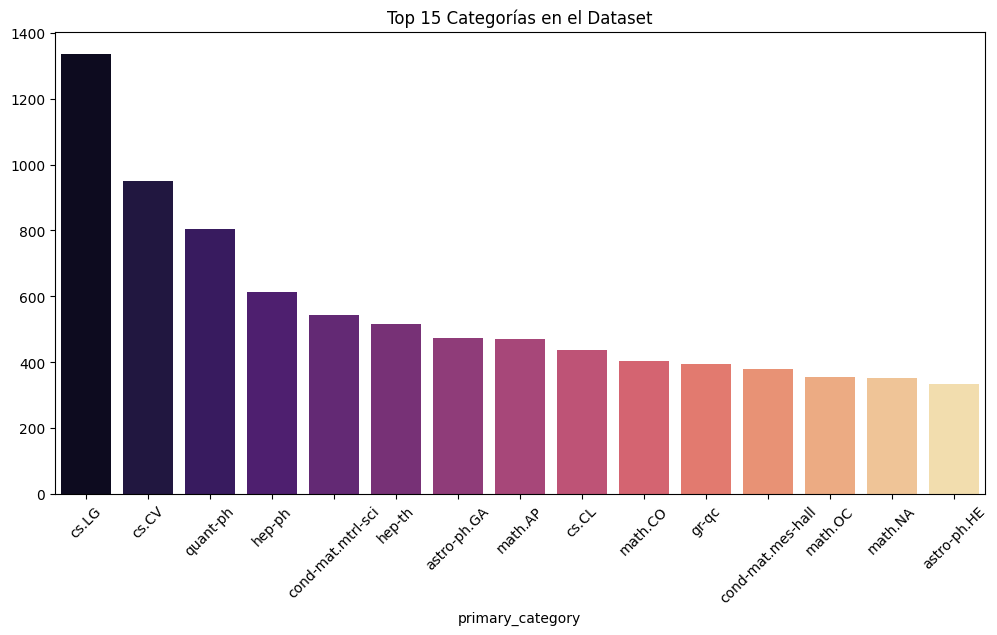

In [13]:
# Ver la distribución de las categorías
category_counts = df_arxiv['primary_category'].value_counts()

print(f"Total de registros: {len(df_arxiv)}")
print(f"Total de categorías únicas: {len(category_counts)}")
print("\nTop 15 categorías más frecuentes:")
print(category_counts.head(15))

# Graficar para visualizar el balance
plt.figure(figsize=(12, 6))
sns.barplot(x=category_counts.index[:15], y=category_counts.values[:15], palette="magma")
plt.title("Top 15 Categorías en el Dataset")
plt.xticks(rotation=45)
plt.show()

In [16]:
text_lengths = [len(text) for text in df_arxiv['abstract']]
print(f"Texto más corto: {min(text_lengths)}")
print(f"Texto más largo: {max(text_lengths)}")
print(f"Longitud promedio: {sum(text_lengths) / len(text_lengths)}")

Texto más corto: 58
Texto más largo: 2763
Longitud promedio: 1070.7085


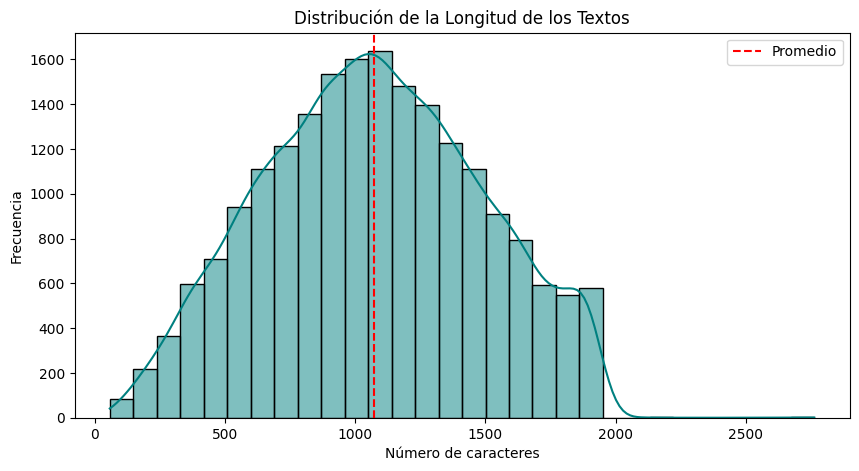

In [23]:
# Suponiendo que 'text_lengths' es la lista que calculaste antes
plt.figure(figsize=(10, 5))
sns.histplot(text_lengths, bins=30, kde=True, color='teal')
plt.axvline(sum(text_lengths) / len(text_lengths), color='red', linestyle='--', label='Promedio')
plt.title('Distribución de la Longitud de los Textos')
plt.xlabel('Número de caracteres')
plt.ylabel('Frecuencia')
plt.legend()
plt.show()

In [35]:
# Descargar recursos necesarios de NLTK
nltk.download('stopwords')
nltk.download('punkt') # Still useful for other NLTK components, though not directly for RegexpTokenizer here
# Removed nltk.download('punkt_tab') as it's not a standard NLTK resource.
# The 'word_tokenize' function usually relies on the 'punkt' tokenizer.

stop_words = set(stopwords.words('english'))

def clean_text(text):
    # 1. Convertir a minúsculas
    text = text.lower()

    # 2. Eliminar comandos de LaTeX simples y símbolos matemáticos
    # Esto quita cosas como $...$ o comandos que empiezan con \
    text = re.sub(r'\$.*?\$', '', text)
    text = re.sub(r'\\(\w+)', '', text)

    # 3. Eliminar caracteres especiales y números
    text = re.sub(r'[^a-zA-Z\s]', '', text)

    # 4. Tokenización y eliminación de stopwords (using RegexpTokenizer)
    tokenizer = RegexpTokenizer(r'\w+') # Simple tokenizer for words
    tokens = tokenizer.tokenize(text)
    filtered_text = [word for word in tokens if word not in stop_words and len(word) > 2]

    return " ".join(filtered_text)

# Aplicar la limpieza a tu dataset
# Suponiendo que tu DataFrame es 'df' y la columna es 'abstract'
print("Limpiando textos... esto puede tardar un poco.")
df_arxiv['cleaned_text'] = df_arxiv['abstract'].apply(clean_text)
print("¡Limpieza completada!")

# Ver un ejemplo del antes y después
print("\nEJEMPLO DE TEXTO LIMPIO:")
print(f"Original: {df_arxiv['abstract'].iloc[0][:100]}...")
print(f"Limpio:   {df_arxiv['cleaned_text'].iloc[0][:100]}...")

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Limpiando textos... esto puede tardar un poco.
¡Limpieza completada!

EJEMPLO DE TEXTO LIMPIO:
Original: In this paper, we address the global stabilization of chains of integrators by means of a bounded st...
Limpio:   paper address global stabilization chains integrators means bounded static feedback law whose first ...


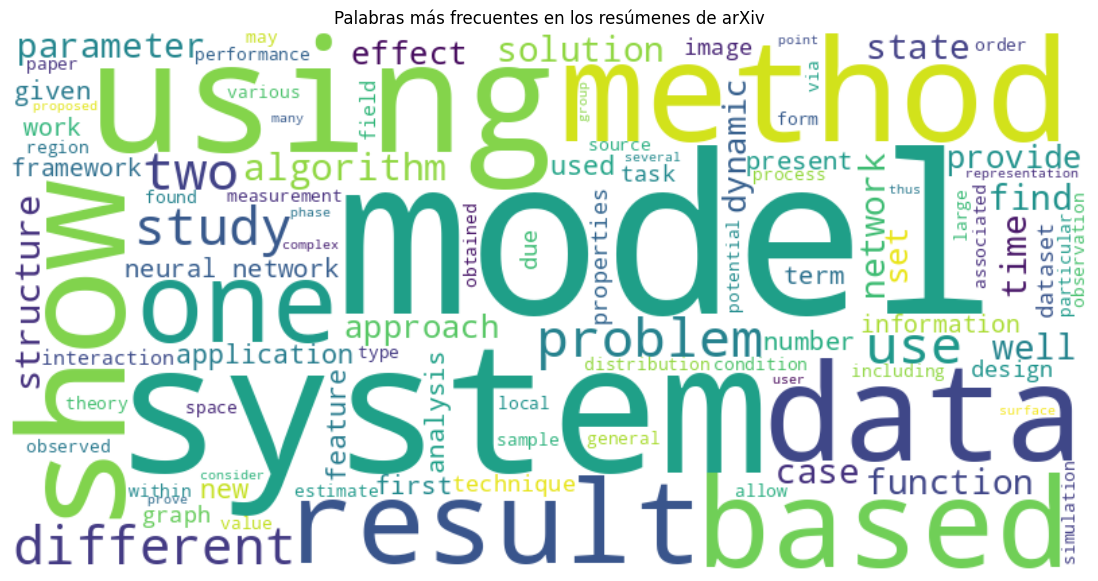

In [38]:
# Unir todos los textos en un solo string
all_words = " ".join(df_arxiv['cleaned_text'])

wordcloud = WordCloud(width=800, height=400,
                      background_color='white',
                      colormap='viridis',
                      max_words=100).generate(all_words)

plt.figure(figsize=(15, 7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Palabras más frecuentes en los resúmenes de arXiv')
plt.show()

In [40]:
le = LabelEncoder()
df_arxiv['category_id'] = le.fit_transform(df_arxiv['primary_category'])

print(f"Número de categorías mapeadas: {len(le.classes_)}")
# Ejemplo de mapeo
mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Mapeo (primeros 5):", list(mapping.items())[:5])

Número de categorías mapeadas: 153
Mapeo (primeros 5): [('astro-ph', np.int64(0)), ('astro-ph.CO', np.int64(1)), ('astro-ph.EP', np.int64(2)), ('astro-ph.GA', np.int64(3)), ('astro-ph.HE', np.int64(4))]


In [41]:
df_arxiv

,id,title,abstract,primary_category,cleaned_text,category_id
0,1503.06364,Global stabilization of multiple integrators b...,"In this paper, we address the global stabiliza...",eess.SY,paper address global stabilization chains inte...,62
1,2011.06295,When deep learning models on GPU can be accele...,This paper is focused on the improvement the e...,cs.LG,paper focused improvement efficiency sparse co...,38
2,2101.01990,Cross-Validation and Uncertainty Determination...,Randomized artificial neural networks such as ...,stat.ML,randomized artificial neural networks extreme ...,150
3,2101.09387,Online Adversarial Purification based on Self-...,Deep neural networks are known to be vulnerabl...,cs.LG,deep neural networks known vulnerable adversar...,38
4,2102.00047,Model Adaptation for Image Reconstruction usin...,Deep learning image reconstruction algorithms ...,cs.LG,deep learning image reconstruction algorithms ...,38
...,...,...,...,...,...,...
19995,2202.04260,Detecting Golodness via GrÃ¶bner Degeneration,In this paper we study the extent to which Gol...,math.AC,paper study extent golodness may transferred a...,69
19996,2202.04262,Parsimonious Learning-Augmented Caching,"Learning-augmented algorithms -- in which, tra...",cs.DS,learningaugmented algorithms traditional algor...,29
19997,2202.04265,Almost sure well-posedness for Hall MHD,We consider the magnetohydrodynamics system wi...,math.AP,consider magnetohydrodynamics system hall effe...,71
19998,2202.04266,MMLN: Leveraging Domain Knowledge for Multimod...,Recent studies show that deep learning models ...,cs.LG,recent studies show deep learning models achie...,38
